In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap
import numpy as np

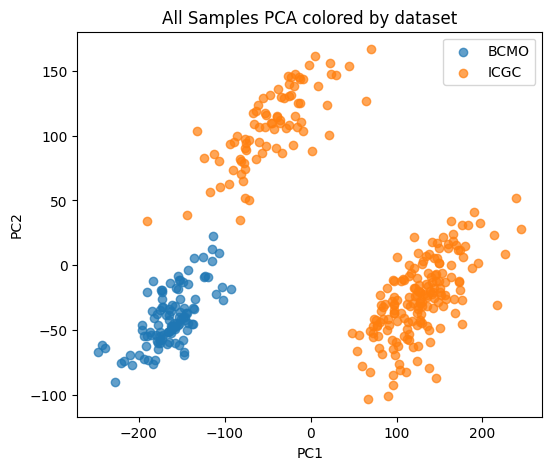

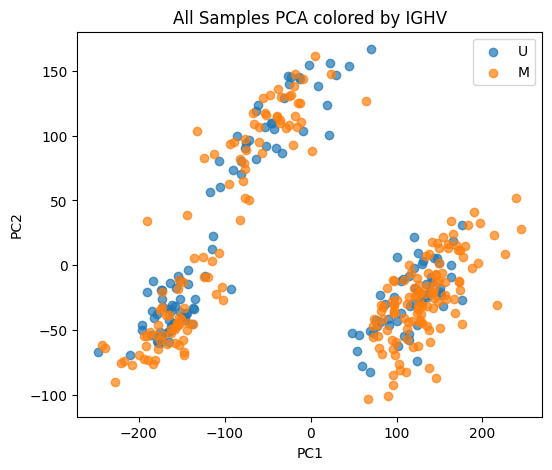

In [3]:
# 1️⃣ Load the count matrices and metadata
bcmo_counts = pd.read_csv("../../data/BCMO/count_matrix.csv", index_col=0)   # genes as rows, samples as columns?
bcmo_meta = pd.read_csv("../../data/BCMO/metadata.csv")

icgc_counts = pd.read_csv("../../data/ICGC/count_matrix.csv", index_col=0)
icgc_meta = pd.read_csv("../../data/ICGC/metadata.csv")

# 2️⃣ Match samples in counts and metadata
# For BCMO
bcmo_counts = bcmo_counts[bcmo_meta["Sample_ID"]]
# 2️⃣ Log2 transform BCMO counts
bcmo_counts = (bcmo_counts + 1).apply(np.log2)

# For ICGC
icgc_counts = icgc_counts[icgc_meta["Samples"]]

# 3️⃣ Keep only common genes
common_genes = bcmo_counts.index.intersection(icgc_counts.index)
bcmo_counts = bcmo_counts.loc[common_genes]
icgc_counts = icgc_counts.loc[common_genes]

# 4️⃣ Define a function to perform PCA and plot
def pca_plot(counts, metadata, color_by, title_prefix):
    # transpose to have samples as rows
    data = counts.T
    
    # PCA
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(data)
    
    # Plot PCA
    plt.figure(figsize=(6,5))
    for status in metadata[color_by].unique():
        idx = metadata[color_by] == status
        plt.scatter(pca_res[idx,0], pca_res[idx,1], label=status, alpha=0.7)
    plt.title(f"{title_prefix} PCA colored by {color_by}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

# 5️⃣ Apply by dataset
bcmo_meta["dataset"] = "BCMO"
icgc_meta["dataset"] = "ICGC"

combined_counts = pd.concat([bcmo_counts, icgc_counts], axis=1)
combined_meta = pd.concat([
    bcmo_meta.rename(columns={"Sample_ID":"Sample"}),
    icgc_meta.rename(columns={"Samples":"Sample"})
], ignore_index=True)

# Align counts to metadata
combined_counts = combined_counts[combined_meta["Sample"]]

# PCA colored by dataset
pca_plot(combined_counts, combined_meta, color_by="dataset", title_prefix="All Samples")

# PCA colored by IGHV status
pca_plot(combined_counts, combined_meta, color_by="IGHV", title_prefix="All Samples")


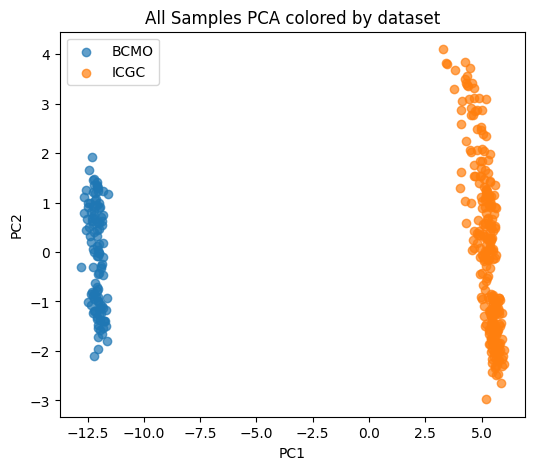

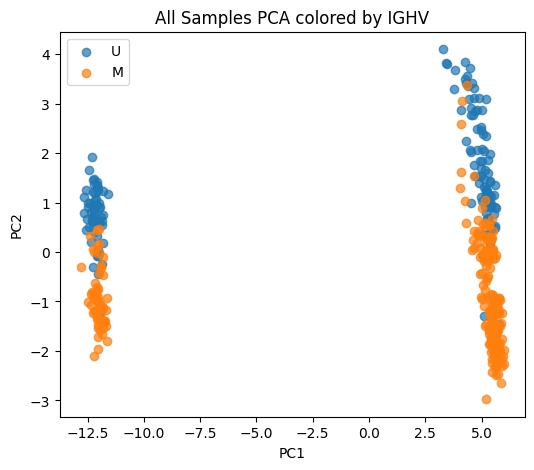

In [6]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1️⃣ Load the count matrices and metadata
bcmo_counts = pd.read_csv("../../data/BCMO/activity_matrix_pvalfilt.csv", index_col=0)
bcmo_meta = pd.read_csv("../../data/BCMO/metadata.csv")

icgc_counts = pd.read_csv("../../data/ICGC/activity_matrix_pvalfilt.csv", index_col=0)
icgc_meta = pd.read_csv("../../data/ICGC/metadata.csv")

# 2️⃣ Match samples in counts and metadata
bcmo_counts = bcmo_counts[bcmo_meta["Sample_ID"]]
icgc_counts = icgc_counts[icgc_meta["Samples"]]

# 3️⃣ Keep only common genes
common_genes = bcmo_counts.index.intersection(icgc_counts.index)
bcmo_counts = bcmo_counts.loc[common_genes]
icgc_counts = icgc_counts.loc[common_genes]

# 4️⃣ Define a function to perform PCA and plot
def pca_plot(counts, metadata, color_by, title_prefix):
    # transpose to have samples as rows
    data = counts.T
    
    # PCA
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(data)
    
    # Plot PCA
    plt.figure(figsize=(6,5))
    for status in metadata[color_by].unique():
        idx = metadata[color_by] == status
        plt.scatter(pca_res[idx,0], pca_res[idx,1], label=status, alpha=0.7)
    plt.title(f"{title_prefix} PCA colored by {color_by}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

# 5️⃣ Apply by dataset
bcmo_meta["dataset"] = "BCMO"
icgc_meta["dataset"] = "ICGC"

combined_counts = pd.concat([bcmo_counts, icgc_counts], axis=1)
combined_meta = pd.concat([
    bcmo_meta.rename(columns={"Sample_ID":"Sample"}),
    icgc_meta.rename(columns={"Samples":"Sample"})
], ignore_index=True)

# Align counts to metadata
combined_counts = combined_counts[combined_meta["Sample"]]

# PCA colored by dataset
pca_plot(combined_counts, combined_meta, color_by="dataset", title_prefix="All Samples")

# PCA colored by IGHV status
pca_plot(combined_counts, combined_meta, color_by="IGHV", title_prefix="All Samples")
